In [1]:
# 薄膜試料向けWPPF関数をインポート
from src.wppf_thin_film import (
    plot_wppf_result_extended,
    wppf_hybrid_thin_film,
    wppf_progressive,
    wppf_with_lattice_correction,
)

print("✓ 薄膜試料向けWPPF関数をインポートしました")

✓ 薄膜試料向けWPPF関数をインポートしました


In [3]:
from pathlib import Path
from src.ras_loader import load_ras_file
from src.cif_loader import get_theoretical_peaks_from_cif

# RASファイルのパスを指定
ras_path = Path(
    r"data\XRD_profiles\XRD\250915_XRD_PB_ID_43_44\ID44_PB_基板加熱100度_高真空_2000W.ras"
)

ras_df = load_ras_file(ras_path)

# GaussianModelで試す（B-splineバックグラウンド込み）

ras_x = ras_df["x"].to_numpy()
ras_y = ras_df["cps"].to_numpy()

peaks_df = get_theoretical_peaks_from_cif(cif_path=Path(r"data\cif\NbTi.cif"))

CIFファイルを読み込み中: NbTi.cif
結晶系: 1
格子定数: a=3.2820 Å
波長: 1.5406 Å (CuKa1)
理論XRDパターンを計算中...
検出されたピーク数: 9
検出されたピーク数: 9
2θ範囲: 19.07 - 83.19°


## アプローチ1: ハイブリッド法（推奨）

実験データで自動検出したピークと理論ピークをマッチングさせる方法。
薄膜試料で理論ピークがすべて観測されない場合に有効です。

=== Hybrid WPPF for Thin Films ===
実験データで検出されたピーク数: 2
ピーク位置: [38.15 69.23]

理論ピークとマッチしたピーク数: 2
マッチしなかったピーク数: 0
フィッティング対象の理論ピーク数: 7
追加された未同定ピーク数: 0
総ピークモデル数: 7
総ピークモデル数: 7

=== フィッティング開始 ===
フィッティング成功: False
警告: Tolerance seems to be too small. Could not estimate error-bars.


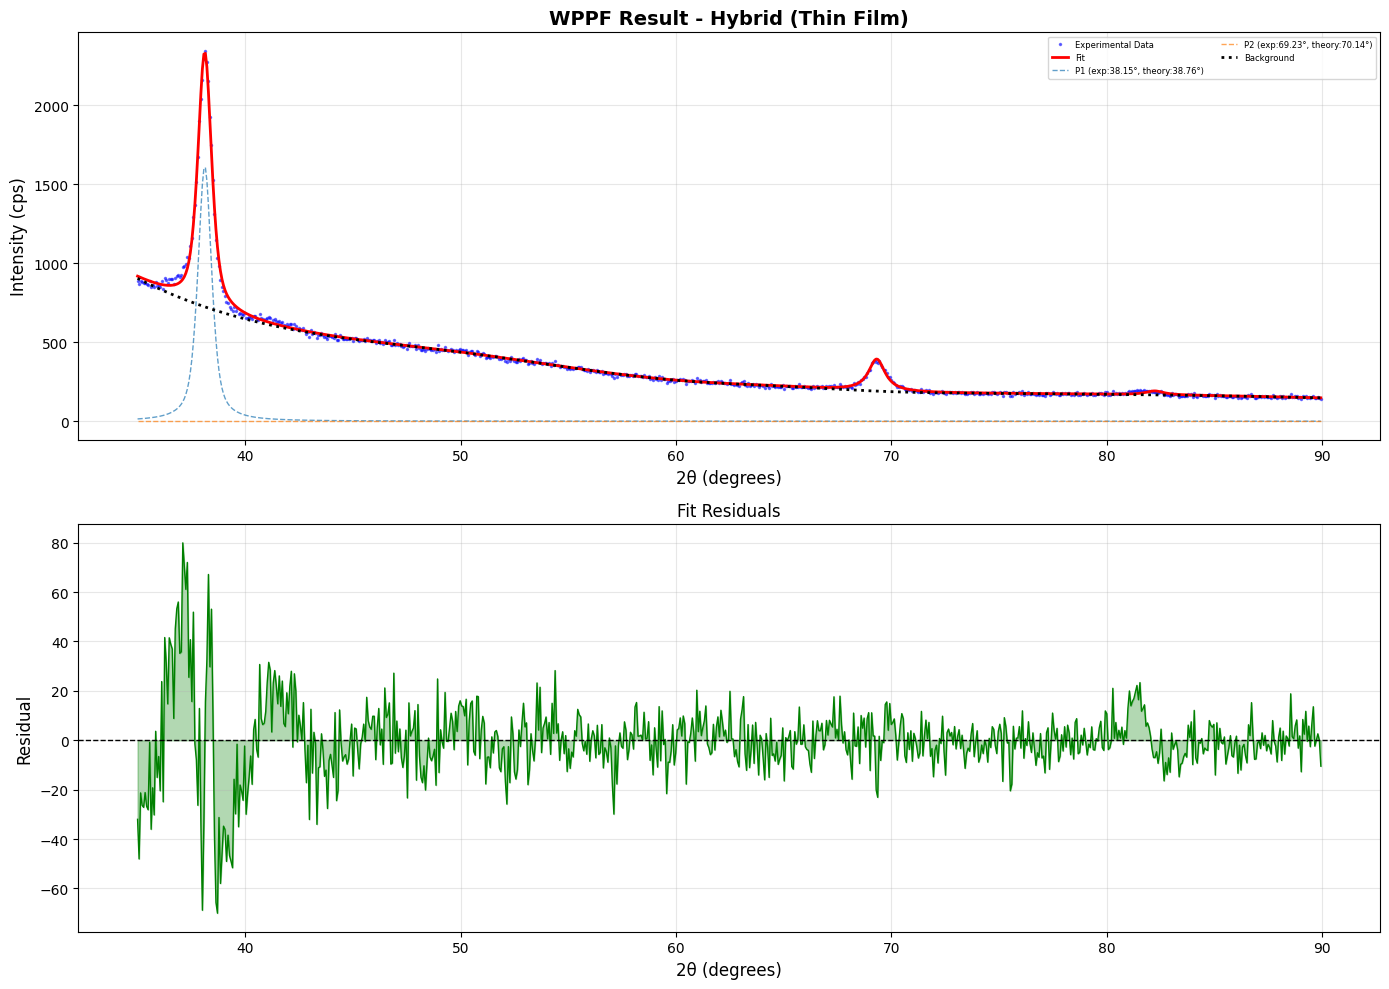


=== Fitting Statistics ===
Chi-squared: 1.7457e+05
Reduced chi-squared: 2.3061e+02
R-squared (R²): 0.997417
AIC: 4304.8498
BIC: 4440.1916

R-factors:
  Rp:  2.70%
  Rwp: 3.38%

格子歪み: 0.499 ± 0.000 %

=== ピークマッチング詳細 ===

マッチしたピーク:
  P1: 実験 38.15° → 理論 38.76° (Δ = 0.614°)
  P2: 実験 69.23° → 理論 70.14° (Δ = 0.908°)


In [5]:
from lmfit.models import PseudoVoigtModel

# 実験データの準備
ras_x = ras_df["x"].to_numpy()
ras_y = ras_df["cps"].to_numpy()

# ハイブリッド法でWPPF実行
if peaks_df is not None:
    result_hybrid = wppf_hybrid_thin_film(
        ras_x,
        ras_y,
        peaks_df,
        PseudoVoigtModel,
        background_type="spline",
        num_knots=10,
        peak_matching_tolerance=5,  # 理論ピークとのマッチング許容範囲（度）
        prominence_factor=0.03,  # ピーク検出の感度
    )

    if result_hybrid is not None:
        # 結果をプロット
        plot_wppf_result_extended(
            ras_x, ras_y, result_hybrid, peaks_df, method="Hybrid (Thin Film)"
        )

        # マッチング情報を表示
        print("\n=== ピークマッチング詳細 ===")
        print("\nマッチしたピーク:")
        for i, peak in enumerate(result_hybrid.matched_peaks):
            print(
                f"  P{i + 1}: 実験 {peak['exp_position']:.2f}° → 理論 {peak['theory_position']:.2f}° "
                f"(Δ = {abs(peak['exp_position'] - peak['theory_position']):.3f}°)"
            )

        if result_hybrid.unmatched_peaks:
            print("\nマッチしなかったピーク（基板または不純物の可能性）:")
            for i, peak in enumerate(result_hybrid.unmatched_peaks):
                print(f"  U{i + 1}: {peak['exp_position']:.2f}°")

## アプローチ2: 格子定数補正付きWPPF

基板応力による格子歪みを考慮し、すべてのピークを同じ比率でシフトさせます。
薄膜の応力状態を定量的に評価できます。

In [ ]:
# 格子定数補正付きWPPF実行
if peaks_df is not None:
    result_lattice = wppf_with_lattice_correction(
        ras_x,
        ras_y,
        peaks_df,
        PseudoVoigtModel,
        background_type="spline",
        num_knots=10,
        allow_lattice_strain=True,  # 格子歪みパラメータを使用
        max_strain_percent=2.0,  # 最大歪み±2%
    )

    if result_lattice is not None:
        # 結果をプロット
        plot_wppf_result_extended(
            ras_x, ras_y, result_lattice, peaks_df, method="Lattice Correction"
        )

        # 格子歪み情報を詳細表示
        strain = result_lattice.params["lattice_strain"].value
        strain_stderr = result_lattice.params["lattice_strain"].stderr or 0

        print("\n=== 格子歪み解析結果 ===")
        print(f"格子歪み: {strain * 100:.3f} ± {strain_stderr * 100:.3f} %")

        if abs(strain) > 0.001:
            if strain > 0:
                print("→ 引張応力が作用している可能性")
                print("  （格子定数が理論値より小さい方向）")
            else:
                print("→ 圧縮応力が作用している可能性")
                print("  （格子定数が理論値より大きい方向）")

            # 各ピークの補正量を表示
            print("\n理論位置からのシフト:")
            for i, row in enumerate(peaks_df.iter_rows(named=True)):
                theory_pos = row["two_theta"]
                corrected_pos = theory_pos * (1 - strain)
                shift = corrected_pos - theory_pos
                print(
                    f"  P{i + 1}: {theory_pos:.2f}° → {corrected_pos:.2f}° (Δ = {shift:.3f}°)"
                )
        else:
            print("→ 格子歪みは無視できる範囲です")

## アプローチ3: 複数相対応WPPF

複数のCIFファイルを使用して、異なる相のピークを同時にフィッティングします。
基板や不純物相が混在する場合に有効です。

In [ ]:
# 複数のCIFファイルから理論ピークを取得
# 例: NbTi合金相と別の相（必要に応じて追加）

# 第2の相のCIFファイルがある場合
# peaks_df_phase2 = get_theoretical_peaks_from_cif(
#     "data/cif/another_phase.cif",
#     wavelength=1.5406,
#     two_theta_range=(20, 90)
# )

# 複数相でWPPF実行（2つ以上のCIFがある場合）
# if peaks_df is not None and peaks_df_phase2 is not None:
#     result_multiphase = wppf_multi_phase(
#         ras_x,
#         ras_y,
#         theoretical_peaks_list=[peaks_df, peaks_df_phase2],
#         phase_names=["NbTi", "Phase2"],
#         model_class=PseudoVoigtModel,
#         background_type="spline",
#         num_knots=10,
#         peak_matching_tolerance=0.5,
#     )
#
#     if result_multiphase is not None:
#         # 結果をプロット
#         plot_wppf_result_extended(
#             ras_x, ras_y, result_multiphase, method="Multi-Phase"
#         )
#
#         # 相割り当て情報を表示
#         print("\n=== 相割り当て結果 ===")
#         for assignment in result_multiphase.phase_assignments:
#             exp_pos = assignment['exp_position']
#             phase = assignment['phase']
#             print(f"  {exp_pos:.2f}° → {phase}")

print("複数相WPPFを使用するには、複数のCIFファイルを指定してください")
print("上記のコメントを外して実行してください")

## アプローチ4: 段階的WPPF

まず強いピークでフィッティングし、次に弱いピークを追加します。
フィッティングの安定性を向上させます。

In [ ]:
# 段階的WPPF実行
if peaks_df is not None:
    result_progressive = wppf_progressive(
        ras_x,
        ras_y,
        peaks_df,
        PseudoVoigtModel,
        background_type="spline",
        num_knots=10,
        intensity_threshold=10.0,  # 第1段階で使用する最小相対強度（%）
    )

    if result_progressive is not None:
        # 結果をプロット
        plot_wppf_result_extended(
            ras_x, ras_y, result_progressive, peaks_df, method="Progressive"
        )

## 薄膜向けWPPF手法の比較

4つのアプローチの統計値を比較して、最適な手法を選択します。

In [ ]:
# 実行した手法の結果を比較
results_comparison = {}

if "result_hybrid" in locals() and result_hybrid is not None:
    results_comparison["Hybrid"] = result_hybrid

if "result_lattice" in locals() and result_lattice is not None:
    results_comparison["Lattice Correction"] = result_lattice

if "result_progressive" in locals() and result_progressive is not None:
    results_comparison["Progressive"] = result_progressive

if len(results_comparison) > 0:
    comparison_data = {
        "Method": [],
        "Chi-squared": [],
        "Reduced χ²": [],
        "R-squared": [],
        "AIC": [],
        "BIC": [],
    }

    for method_name, result in results_comparison.items():
        comparison_data["Method"].append(method_name)
        comparison_data["Chi-squared"].append(result.chisqr)
        comparison_data["Reduced χ²"].append(result.redchi)
        comparison_data["R-squared"].append(result.rsquared)
        comparison_data["AIC"].append(result.aic)
        comparison_data["BIC"].append(result.bic)

    comparison_df = pl.DataFrame(comparison_data)
    print("\n=== 薄膜向けWPPF手法の比較 ===")
    print(comparison_df)

    # 最良の手法を判定
    best_r2_idx = comparison_df["R-squared"].arg_max()
    best_aic_idx = comparison_df["AIC"].arg_min()

    print("\n=== 推奨手法 ===")
    print(
        f"✓ 最高R²値: {comparison_df['Method'][best_r2_idx]} (R² = {comparison_df['R-squared'][best_r2_idx]:.6f})"
    )
    print(
        f"✓ 最低AIC値: {comparison_df['Method'][best_aic_idx]} (AIC = {comparison_df['AIC'][best_aic_idx]:.2f})"
    )

    print("\n手法選択のガイドライン:")
    print(
        "  - Hybrid法: 理論ピークと実験ピークが一部一致しない場合に推奨（薄膜の一般的なケース）"
    )
    print("  - Lattice Correction: 応力による格子歪みを定量化したい場合に推奨")
    print("  - Progressive: フィッティングが不安定な場合に推奨")
else:
    print("比較する結果がありません。上記のセルを実行してください。")